# Exercise 6.3 — A-B-C Three-Component System

**Source:** Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Exercise 6.3

---

## Problem

Three components A, B, C each hold a real-valued state in \[-1, 1\]. At every time step:

- **A** → takes B's current state
- **B** → takes C's current state
- **C** → takes the average of A and B's current states

Build a **discrete-time** model, then convert to **continuous-time** using Eq. 6.25:

$$B \Leftrightarrow \frac{A - I}{\Delta t}$$

(where $A$ is the update matrix and $I$ is the identity — calling the continuous generator $B$ to avoid name collision with our component B below).

---

## Part 1 — Discrete-Time Model

Let the state vector be $\mathbf{x}(t) = [x_A(t),\ x_B(t),\ x_C(t)]^\top$.  
The three rules give us one matrix equation $\mathbf{x}(t) = M\,\mathbf{x}(t-1)$:

$$
\begin{bmatrix} x_A(t) \\ x_B(t) \\ x_C(t) \end{bmatrix}
=
\underbrace{\begin{bmatrix}
0 & 1 & 0 \\
0 & 0 & 1 \\
\tfrac{1}{2} & \tfrac{1}{2} & 0
\end{bmatrix}}_{M}
\begin{bmatrix} x_A(t-1) \\ x_B(t-1) \\ x_C(t-1) \end{bmatrix}
$$

Reading off the rows:
- Row 1: $x_A(t) = x_B(t-1)$ ✓
- Row 2: $x_B(t) = x_C(t-1)$ ✓
- Row 3: $x_C(t) = \tfrac{1}{2}x_A(t-1) + \tfrac{1}{2}x_B(t-1)$ ✓

---

## Part 2 — Eigenvalue Analysis of M

Find $\det(M - \lambda I) = 0$. Expanding the $3\times 3$ determinant:

$$
\det\begin{bmatrix}
-\lambda & 1 & 0 \\
0 & -\lambda & 1 \\
\tfrac{1}{2} & \tfrac{1}{2} & -\lambda
\end{bmatrix}
= -\lambda(\lambda^2 - \tfrac{1}{2}) - 1(0 - \tfrac{1}{2}) = 0
$$

$$
-\lambda^3 + \tfrac{\lambda}{2} + \tfrac{1}{2} = 0
\quad\Longrightarrow\quad
2\lambda^3 - \lambda - 1 = 0
$$

Factor: try $\lambda = 1$ → $2 - 1 - 1 = 0$ ✓, so $(\lambda - 1)$ is a factor.

$$
2\lambda^3 - \lambda - 1 = (\lambda - 1)(2\lambda^2 + 2\lambda + 1) = 0
$$

Quadratic formula on $2\lambda^2 + 2\lambda + 1 = 0$:

$$
\lambda = \frac{-2 \pm \sqrt{4 - 8}}{4} = \frac{-1 \pm i}{2}
$$

So the three eigenvalues of $M$ are:

| Eigenvalue | Magnitude | Interpretation |
|---|---|---|
| $\lambda_1 = 1$ | $\lvert\lambda_1\rvert = 1$ | Neutral / conserved mode |
| $\lambda_2 = \frac{-1+i}{2}$ | $\lvert\lambda_2\rvert = \frac{1}{\sqrt{2}} \approx 0.707$ | Decaying oscillation |
| $\lambda_3 = \frac{-1-i}{2}$ | $\lvert\lambda_3\rvert = \frac{1}{\sqrt{2}} \approx 0.707$ | Decaying oscillation (conjugate) |

Since $|\lambda_{2,3}| < 1$, those modes shrink every step. $\lambda_1 = 1$ is what survives long-term.

---

## Part 3 — Conserved Quantity

The left eigenvector $\mathbf{w}$ for $\lambda_1 = 1$ satisfies $\mathbf{w}^\top M = \mathbf{w}^\top$.
Solving row by row gives $\mathbf{w} = [1, 2, 2]$ (up to scaling).

This means $\mathbf{w}^\top \mathbf{x}(t) = \mathbf{w}^\top M \mathbf{x}(t-1) = \mathbf{w}^\top \mathbf{x}(t-1)$, so:

$$
\boxed{x_A(t) + 2x_B(t) + 2x_C(t) = \text{const} = x_A(0) + 2x_B(0) + 2x_C(0)}
$$

Quick check: $x_A(t) + 2x_B(t) + 2x_C(t) = x_B(t\!-\!1) + 2x_C(t\!-\!1) + x_A(t\!-\!1) + x_B(t\!-\!1) = x_A(t\!-\!1) + 2x_B(t\!-\!1) + 2x_C(t\!-\!1)$ ✓

**Asymptotic state:** As $t \to \infty$ all three components converge to the same value $v$.
Plug into the conserved quantity: $v + 2v + 2v = 5v = x_A(0) + 2x_B(0) + 2x_C(0)$, so:

$$
v = \frac{x_A(0) + 2x_B(0) + 2x_C(0)}{5}
$$

---

## Part 4 — Continuous-Time Model via Eq. 6.25

Eq. 6.25 says the continuous generator $\mathcal{B}$ is related to the discrete update matrix $M$ by:

$$
\mathcal{B} = \frac{M - I}{\Delta t}
$$

With $\Delta t = 1$ (one time step per unit time):

$$
\mathcal{B} = M - I =
\begin{bmatrix}
-1 & 1 & 0 \\
0 & -1 & 1 \\
\tfrac{1}{2} & \tfrac{1}{2} & -1
\end{bmatrix}
$$

The ODE system $\dot{\mathbf{x}} = \mathcal{B}\,\mathbf{x}$ expands to:

$$
\frac{dx_A}{dt} = -x_A + x_B, \qquad
\frac{dx_B}{dt} = -x_B + x_C, \qquad
\frac{dx_C}{dt} = \tfrac{1}{2}x_A + \tfrac{1}{2}x_B - x_C
$$

Eigenvalues of $\mathcal{B}$ are just $\mu_k = \lambda_k - 1$:

| Eigenvalue | Real part | Interpretation |
|---|---|---|
| $\mu_1 = 0$ | 0 | Conserved mode |
| $\mu_2 = \frac{-3+i}{2}$ | $-\frac{3}{2}$ | Decaying oscillation |
| $\mu_3 = \frac{-3-i}{2}$ | $-\frac{3}{2}$ | Decaying oscillation (conjugate) |

Re($\mu_{2,3}$) $< 0$ → those modes decay exponentially. $\mu_1 = 0$ → that direction is flat (conserved). Same conserved quantity $x_A + 2x_B + 2x_C$ holds in continuous time too.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ─── Build the discrete update matrix M ───────────────────────────────────────
# Row 0: x_A(t) = x_B(t-1)           → [0, 1, 0]
# Row 1: x_B(t) = x_C(t-1)           → [0, 0, 1]
# Row 2: x_C(t) = (x_A+x_B)/2 (t-1)  → [0.5, 0.5, 0]
M = np.array([[0,   1,   0  ],
              [0,   0,   1  ],
              [0.5, 0.5, 0  ]])

# ─── Continuous generator B = (M - I) / Δt, with Δt = 1 ──────────────────────
B_gen = M - np.eye(3)

print("Discrete update matrix M:")
print(M)
print()
print("Continuous generator B = M - I:")
print(B_gen)
print()

# Quick sanity check: row sums of M should all be 1 (it's a stochastic-like matrix)
print("Row sums of M:", M.sum(axis=1))  # [1, 1, 1]

Discrete update matrix M:
[[0.  1.  0. ]
 [0.  0.  1. ]
 [0.5 0.5 0. ]]

Continuous generator B = M - I:
[[-1.   1.   0. ]
 [ 0.  -1.   1. ]
 [ 0.5  0.5 -1. ]]

Row sums of M: [1. 1. 1.]


In [2]:
# ─── Eigenvalue analysis — discrete M ─────────────────────────────────────────
evals_M, evecs_M = np.linalg.eig(M)

print("Eigenvalues of M:")
for k, lam in enumerate(evals_M):
    print(f"  λ{k+1} = {lam:.4f}   |λ| = {abs(lam):.4f}")

print()

# ─── Eigenvalue analysis — continuous generator B ─────────────────────────────
evals_B, evecs_B = np.linalg.eig(B_gen)

print("Eigenvalues of B = M - I:")
for k, mu in enumerate(evals_B):
    print(f"  μ{k+1} = {mu:.4f}   Re(μ) = {mu.real:.4f}")

print()

# ─── Left eigenvector for λ=1 (find conserved quantity) ───────────────────────
# Left eigenvector satisfies w @ M = w, i.e. (M^T - I) w = 0
evals_MT, evecs_MT = np.linalg.eig(M.T)

# Find the eigenvector corresponding to eigenvalue closest to 1
idx = np.argmin(np.abs(evals_MT - 1.0))
w = evecs_MT[:, idx].real
w = w / w[0]  # normalize so first component is 1

print(f"Left eigenvector for λ=1 (proportional to [1, 2, 2]):")
print(f"  w = {w}")
print(f"  → conserved quantity: {w[0]:.2f}·x_A + {w[1]:.2f}·x_B + {w[2]:.2f}·x_C = const")

Eigenvalues of M:
  λ1 = -0.5000+0.5000j   |λ| = 0.7071
  λ2 = -0.5000-0.5000j   |λ| = 0.7071
  λ3 = 1.0000+0.0000j   |λ| = 1.0000

Eigenvalues of B = M - I:
  μ1 = -1.5000+0.5000j   Re(μ) = -1.5000
  μ2 = -1.5000-0.5000j   Re(μ) = -1.5000
  μ3 = 0.0000+0.0000j   Re(μ) = 0.0000

Left eigenvector for λ=1 (proportional to [1, 2, 2]):
  w = [1. 2. 2.]
  → conserved quantity: 1.00·x_A + 2.00·x_B + 2.00·x_C = const


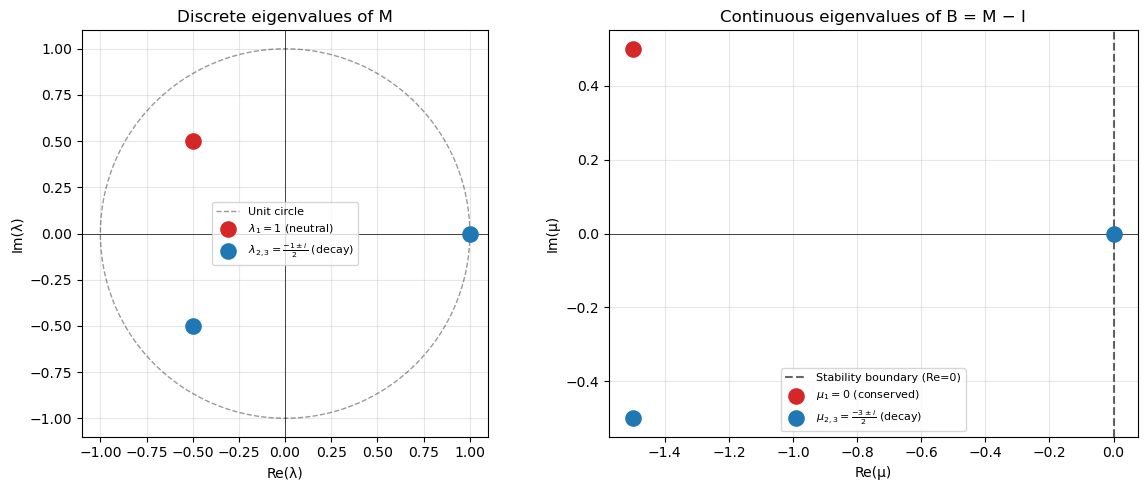

In [3]:
# ─── Eigenvalue plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: unit circle plot for discrete eigenvalues
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=1, alpha=0.4, label='Unit circle')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)

colors = ['tab:red', 'tab:blue', 'tab:blue']
labels = [r'$\lambda_1=1$ (neutral)', r'$\lambda_{2,3}=\frac{-1\pm i}{2}$ (decay)', None]
for k, (lam, c, lab) in enumerate(zip(evals_M, colors, labels)):
    ax.scatter(lam.real, lam.imag, s=120, color=c, zorder=5, label=lab)

ax.set_xlabel('Re(λ)')
ax.set_ylabel('Im(λ)')
ax.set_title('Discrete eigenvalues of M')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: left half-plane plot for continuous eigenvalues
ax = axes[1]
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=1.5, ls='--', alpha=0.6, label='Stability boundary (Re=0)')

colors_c = ['tab:red', 'tab:blue', 'tab:blue']
labels_c = [r'$\mu_1=0$ (conserved)', r'$\mu_{2,3}=\frac{-3\pm i}{2}$ (decay)', None]
for k, (mu, c, lab) in enumerate(zip(evals_B, colors_c, labels_c)):
    ax.scatter(mu.real, mu.imag, s=120, color=c, zorder=5, label=lab)

ax.set_xlabel('Re(μ)')
ax.set_ylabel('Im(μ)')
ax.set_title('Continuous eigenvalues of B = M − I')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ─── Simulate the discrete model ──────────────────────────────────────────────
def simulate_discrete(x0, steps=40):
    """Iterate x(t) = M @ x(t-1) for a given initial condition."""
    traj = [x0.copy()]
    x = x0.copy()
    for _ in range(steps):
        x = M @ x
        traj.append(x.copy())
    return np.array(traj)  # shape (steps+1, 3)


# Initial condition: A=1, B=-1, C=0  (something interesting, not symmetric)
x0 = np.array([1.0, -1.0, 0.0])
traj = simulate_discrete(x0, steps=40)

# Predicted asymptote from conserved quantity
v_pred = (x0[0] + 2*x0[1] + 2*x0[2]) / 5
print(f"Initial condition: A={x0[0]}, B={x0[1]}, C={x0[2]}")
print(f"Conserved quantity A+2B+2C = {x0[0]+2*x0[1]+2*x0[2]:.4f}")
print(f"Predicted asymptote v = (A+2B+2C)/5 = {v_pred:.4f}")
print(f"Final states:  A={traj[-1,0]:.4f}, B={traj[-1,1]:.4f}, C={traj[-1,2]:.4f}")

# Verify conserved quantity stays constant
conserved = traj[:,0] + 2*traj[:,1] + 2*traj[:,2]
print(f"Range of A+2B+2C over time: [{conserved.min():.6f}, {conserved.max():.6f}]  (should be constant)")

Initial condition: A=1.0, B=-1.0, C=0.0
Conserved quantity A+2B+2C = -1.0000
Predicted asymptote v = (A+2B+2C)/5 = -0.2000
Final states:  A=-0.2000, B=-0.2000, C=-0.2000
Range of A+2B+2C over time: [-1.000000, -1.000000]  (should be constant)


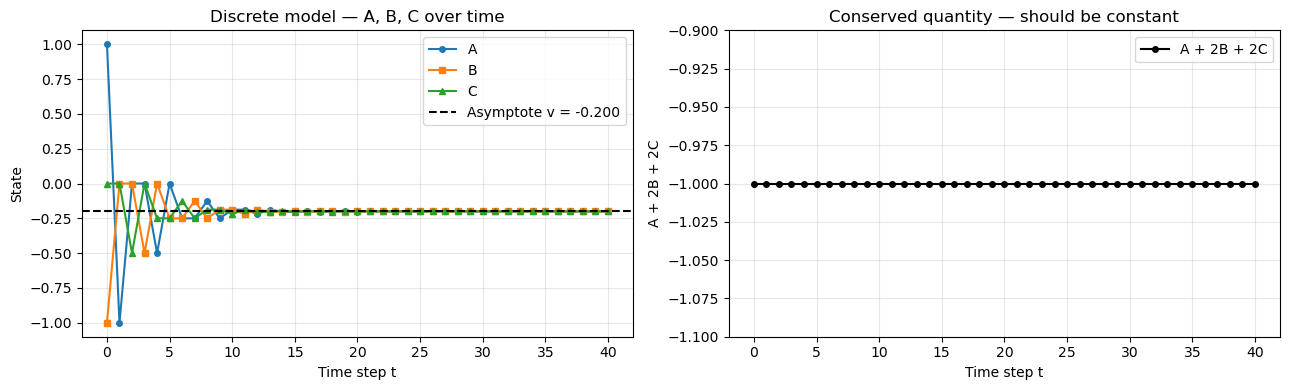

In [5]:
# ─── Plot discrete trajectories ───────────────────────────────────────────────
t_disc = np.arange(len(traj))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time series
ax = axes[0]
ax.plot(t_disc, traj[:,0], 'o-', ms=4, label='A', color='tab:blue')
ax.plot(t_disc, traj[:,1], 's-', ms=4, label='B', color='tab:orange')
ax.plot(t_disc, traj[:,2], '^-', ms=4, label='C', color='tab:green')
ax.axhline(v_pred, color='k', ls='--', lw=1.5, label=f'Asymptote v = {v_pred:.3f}')
ax.set_xlabel('Time step t')
ax.set_ylabel('State')
ax.set_title('Discrete model — A, B, C over time')
ax.legend()
ax.grid(True, alpha=0.3)

# Conserved quantity (should be flat)
ax = axes[1]
ax.plot(t_disc, conserved, 'k-o', ms=4, label='A + 2B + 2C')
ax.set_xlabel('Time step t')
ax.set_ylabel('A + 2B + 2C')
ax.set_title('Conserved quantity — should be constant')
ax.set_ylim([conserved.mean() - 0.1, conserved.mean() + 0.1])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# ─── Simulate the continuous-time ODE system ──────────────────────────────────
# dA/dt = -A + B
# dB/dt = -B + C
# dC/dt =  A/2 + B/2 - C
# Equivalently: dx/dt = B_gen @ x

def ode_rhs(_t, x):
    return B_gen @ x


t_span = (0, 10)  # 10 continuous time units (≈ 10 discrete steps with Δt=1)
t_eval = np.linspace(0, 10, 500)

sol = solve_ivp(ode_rhs, t_span, x0, t_eval=t_eval, method='RK45', rtol=1e-9)

# Predicted asymptote is the same (same conserved quantity)
print("ODE final states:")
print(f"  A(10)={sol.y[0,-1]:.4f}, B(10)={sol.y[1,-1]:.4f}, C(10)={sol.y[2,-1]:.4f}")
print(f"  Predicted v = {v_pred:.4f}")

ODE final states:
  A(10)=-0.2000, B(10)=-0.2000, C(10)=-0.2000
  Predicted v = -0.2000


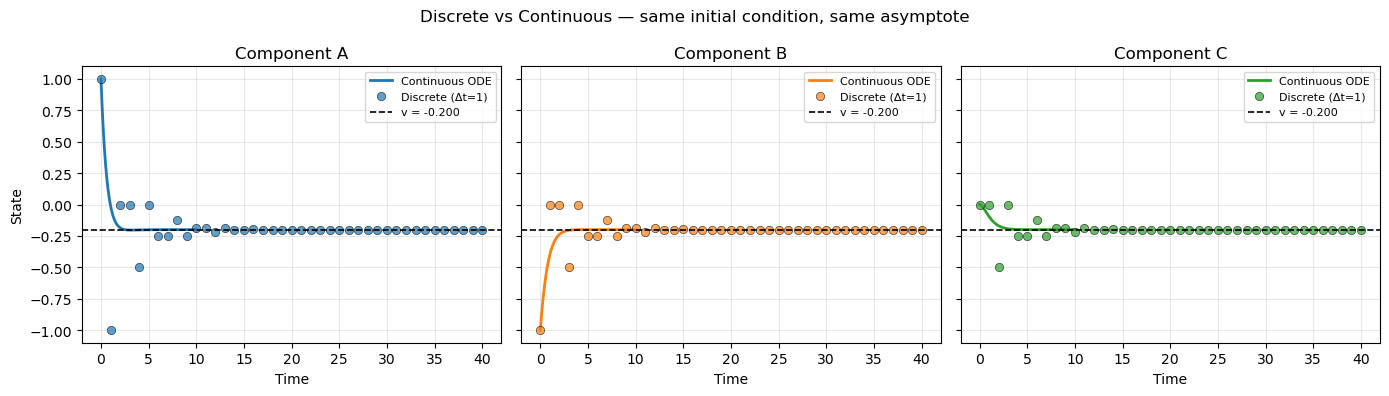

In [7]:
# ─── Compare discrete vs continuous trajectories ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
component_names = ['A', 'B', 'C']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, (name, color) in enumerate(zip(component_names, colors)):
    ax = axes[i]
    ax.plot(sol.t, sol.y[i], '-', lw=2, color=color, label='Continuous ODE')
    ax.plot(t_disc, traj[:,i], 'o', ms=6, color=color, alpha=0.7,
            markeredgecolor='k', markeredgewidth=0.5, label='Discrete (Δt=1)')
    ax.axhline(v_pred, color='k', ls='--', lw=1.2, label=f'v = {v_pred:.3f}')
    ax.set_xlabel('Time')
    ax.set_title(f'Component {name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('State')
fig.suptitle('Discrete vs Continuous — same initial condition, same asymptote', fontsize=12)
plt.tight_layout()
plt.show()

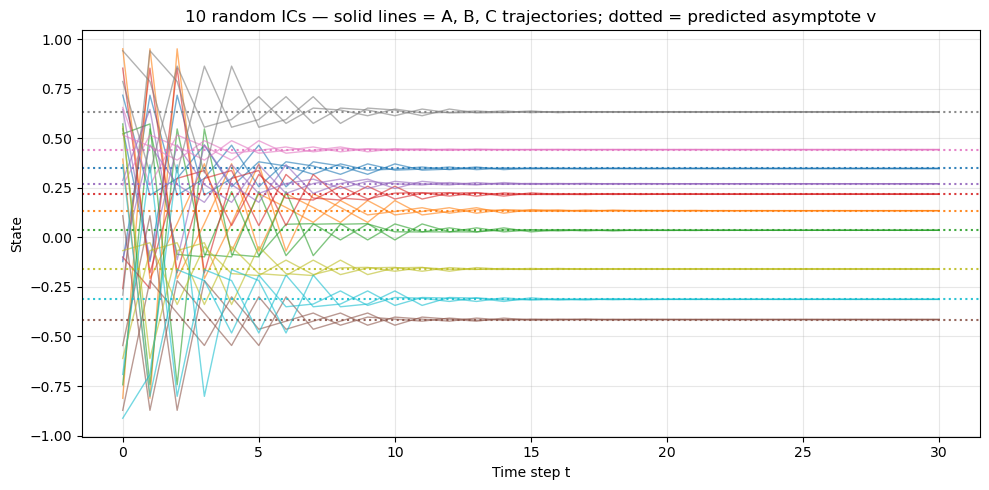

In [8]:
# ─── Multiple random initial conditions — all converge to predicted v ─────────
rng = np.random.default_rng(seed=42)
n_ics = 10
initial_conditions = rng.uniform(-1, 1, size=(n_ics, 3))  # random ICs in [-1, 1]

fig, ax = plt.subplots(figsize=(10, 5))

for k, ic in enumerate(initial_conditions):
    tr = simulate_discrete(ic, steps=30)
    v_k = (ic[0] + 2*ic[1] + 2*ic[2]) / 5
    t_k = np.arange(len(tr))
    # Plot all three components for this IC in the same color; dashed asymptote
    col = plt.cm.tab10(k / n_ics)
    for j in range(3):
        ax.plot(t_k, tr[:, j], '-', color=col, lw=1, alpha=0.6)
    ax.axhline(v_k, color=col, ls=':', lw=1.5, alpha=0.9)

ax.set_xlabel('Time step t')
ax.set_ylabel('State')
ax.set_title('10 random ICs — solid lines = A, B, C trajectories; dotted = predicted asymptote v')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Property | Discrete ($M$) | Continuous ($\mathcal{B} = M - I$) |
|---|---|---|
| Update rule | $\mathbf{x}(t) = M\,\mathbf{x}(t-1)$ | $\dot{\mathbf{x}} = \mathcal{B}\,\mathbf{x}$ |
| Eigenvalue 1 | $\lambda_1 = 1$, $|\lambda_1|=1$ | $\mu_1 = 0$, Re$(\mu_1)=0$ |
| Eigenvalues 2,3 | $\lambda_{2,3} = \frac{-1\pm i}{2}$, $|\lambda|=\frac{1}{\sqrt{2}}$ | $\mu_{2,3} = \frac{-3\pm i}{2}$, Re$=-\frac{3}{2}$ |
| Stability | Decaying oscillation toward conserved subspace | Exponential decay toward conserved subspace |
| Conserved quantity | $x_A + 2x_B + 2x_C = $ const | Same |
| Asymptote | $v = \frac{x_A(0)+2x_B(0)+2x_C(0)}{5}$ | Same |

**Key takeaways:**
- The three components reach a **common consensus value** regardless of initial conditions — but *which* consensus value depends on the initial state via the conserved quantity.
- The conserved quantity $x_A + 2x_B + 2x_C$ comes from the left eigenvector $[1,2,2]$ of $M$ for $\lambda=1$. Component C gets weight 2 because it influences A and B indirectly through the averaging rule.
- Converting to continuous time via Eq. 6.25 ($\mathcal{B} = (M-I)/\Delta t$) just shifts all eigenvalues left by 1, turning neutral $\lambda=1$ into zero $\mu=0$ and turning sub-unit $\lambda$'s into negative-real-part $\mu$'s — same qualitative story, different timescale.